# Conceitos Teóricos — Guia de apoio aos notebooks do projeto

Este notebook é **material de apoio**.
Ele explica, com exemplos pequenos e dados sintéticos (não os dados reais da pesquisa), as
principais técnicas usadas nos notebooks `02_AreaDePonderacao_IC.ipynb` e
`03_SetorCensitario_IC.ipynb`:

1. [Random Forest](#1-random-forest)
2. [Por que trocamos XGBoost por Random Forest?](#2-por-que-trocamos-xgboost-por-random-forest)
3. [SHAP (SHapley Additive exPlanations)](#3-shap-shapley-additive-explanations)
4. [Permutation Importance](#4-permutation-importance)
5. [Desagregação espacial por escores de propensão](#5-desagregação-espacial-por-escores-de-propensão)
6. [Autocorrelação espacial: Índice de Moran e LISA](#6-autocorrelação-espacial-índice-de-moran-e-lisa)

Todos os exemplos aqui rodam em segundos, sem precisar dos arquivos de dados do projeto —
o objetivo é apenas construir intuição antes de mexer nos resultados reais.


## 1. Random Forest

Random Forest é um algoritmo de **aprendizado em conjunto (ensemble)**: em vez de treinar uma
única árvore de decisão, ele treina **centenas de árvores diferentes** e tira a média das
previsões de todas elas.

Duas fontes de aleatoriedade tornam as árvores diferentes entre si:

- **Bootstrap:** cada árvore é treinada em uma amostra aleatória (com reposição) dos dados
  originais — algumas observações aparecem repetidas, outras ficam de fora.
- **Seleção aleatória de variáveis:** em cada divisão (nó) da árvore, apenas um subconjunto
  aleatório das variáveis é considerado, em vez de todas.

O resultado é um conjunto de árvores "diferentes o suficiente" entre si, cuja média tende a ser
mais estável e a generalizar melhor do que qualquer árvore individual — porque os erros
individuais de cada árvore, sendo parcialmente independentes, tendem a se cancelar.

### Demonstração: uma árvore vs. uma floresta

Abaixo, treinamos uma única árvore de decisão e uma Random Forest no mesmo problema sintético
(uma curva com ruído) e comparamos as previsões.


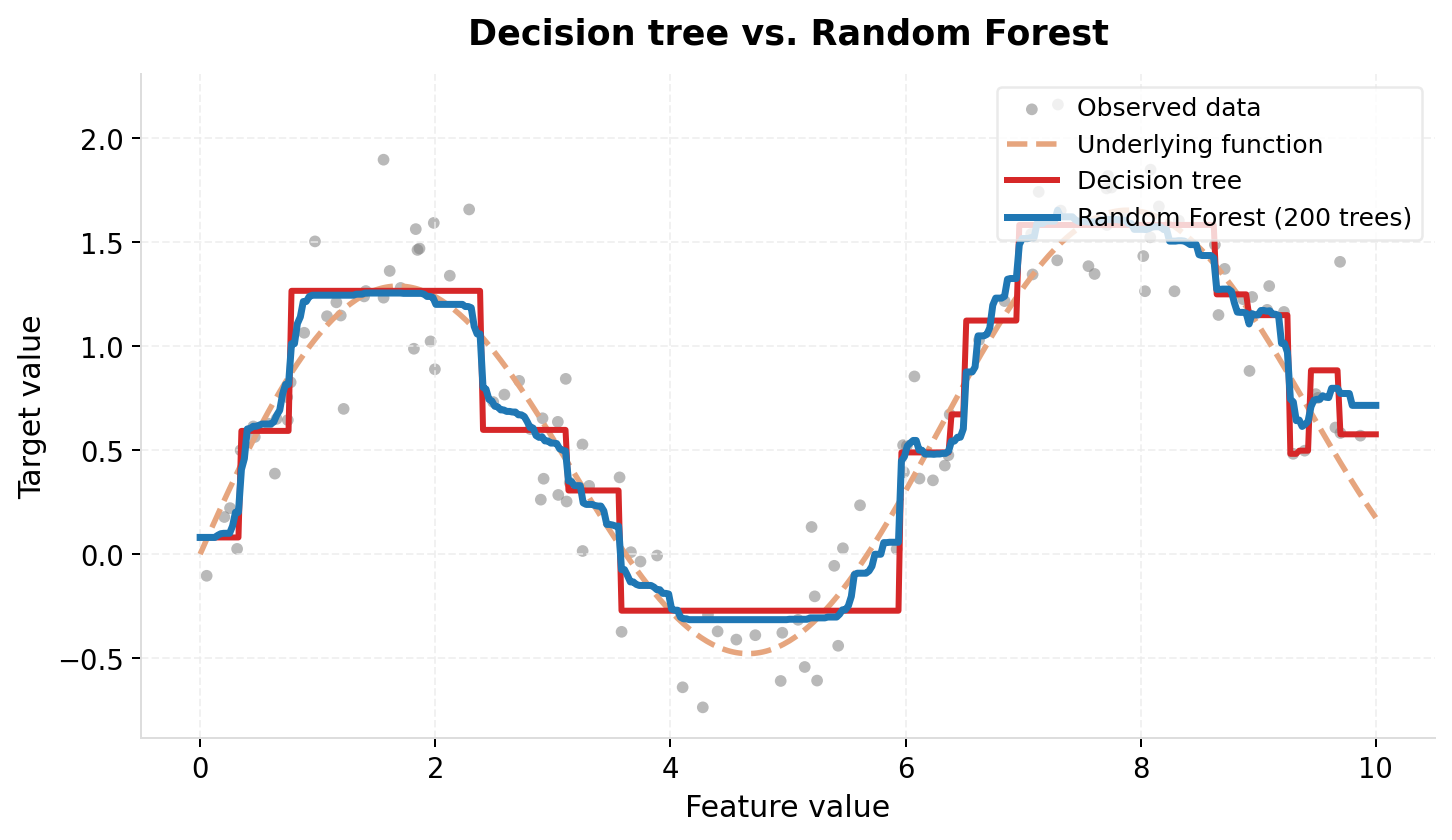

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# Dados sintéticos
# -----------------------------
rng = np.random.RandomState(42)

X = np.sort(rng.uniform(0, 10, 120)).reshape(-1, 1)
y_real = np.sin(X).ravel() + 0.3 * np.log1p(X).ravel()
y = y_real + rng.normal(0, 0.25, size=X.shape[0])

# -----------------------------
# Modelos
# -----------------------------
arvore_unica = DecisionTreeRegressor(
    max_depth=4,
    random_state=0
).fit(X, y)

floresta = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    random_state=0
).fit(X, y)

X_plot = np.linspace(0, 10, 400).reshape(-1, 1)

# -----------------------------
# Estilo visual
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (8.2, 4.8),
    "figure.dpi": 180,
    "font.size": 11,
    "font.family": "DejaVu Sans",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#DDDDDD",
    "axes.linewidth": 0.8,
    "grid.color": "#ECECEC",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
})

fig, ax = plt.subplots()

# Dados observados
ax.scatter(
    X, y,
    s=22,
    color="gray",
    alpha=0.55,
    edgecolors="none",
    label="Observed data"
)

# Curva real
ax.plot(
    X_plot,
    np.sin(X_plot).ravel() + 0.3 * np.log1p(X_plot).ravel(),
    color="#E6A57E",
    lw=2.2,
    linestyle="--",
    label="Underlying function"
)

# Árvore única
ax.plot(
    X_plot,
    arvore_unica.predict(X_plot),
    color="tab:red",
    lw=2.4,
    label="Decision tree"
)

# Random Forest
ax.plot(
    X_plot,
    floresta.predict(X_plot),
    color="tab:blue",
    lw=2.8,
    label="Random Forest (200 trees)"
)

# Layout
ax.set_title(
    "Decision tree vs. Random Forest",
    fontsize=14,
    weight="semibold",
    pad=12
)

ax.set_xlabel("Feature value")
ax.set_ylabel("Target value")
ax.grid(True)

# Bordas elegantes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legenda
leg = ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#E5E5E5",
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()
plt.show()

Repare como a árvore única (vermelho) forma "degraus" abruptos, muito sensíveis ao ruído local dos
dados — um sintoma de **overfitting**. A Random Forest (azul), por tirar a média de muitas árvores
treinadas em amostras ligeiramente diferentes, produz uma curva mais suave, que tende a
generalizar melhor para dados novos. É exatamente essa propriedade que motivou seu uso no projeto:
com um número relativamente pequeno de Áreas de Ponderação disponíveis para treino, um modelo
menos sujeito a overfitting é preferível.


## 2. Por que trocamos XGBoost por Random Forest?

Na fase exploratória (notebook `02`), o projeto usou **XGBoost (Gradient Boosting)**. Na fase
final (notebook `03`), a escolha passou a ser **Random Forest**. Os dois são "florestas de
árvores", mas funcionam de formas bem diferentes:

| | Random Forest (*bagging*) | XGBoost (*boosting*) |
|---|---|---|
| Como as árvores se relacionam | Treinadas **de forma independente**, em paralelo | Treinadas **sequencialmente**: cada árvore nova tenta corrigir o erro (resíduo) da anterior |
| Efeito principal | Reduz **variância** (suaviza previsões, evita overfitting) | Reduz **viés** (aprende padrões finos, pode se ajustar bem a pequenos detalhes) |
| Sensibilidade a poucos dados | Menor — cada árvore já é relativamente robusta sozinha | Maior — o encadeamento sequencial pode amplificar padrões espúrios quando há poucas observações |
| Necessidade de ajuste de hiperparâmetros | Menor (funciona bem com poucos ajustes) | Maior (learning rate, profundidade, nº de árvores interagem fortemente) |

No contexto deste projeto, o número de Áreas de Ponderação disponíveis para treino é
relativamente pequeno (uma linha por AP, versus dezenas de milhares de setores nas *features* de
downscaling). Nesse regime, o comportamento mais conservador do Random Forest — que já apareceu
na demonstração acima — se mostrou mais **estável na validação cruzada** do que o XGBoost, motivo
da mudança de algoritmo entre as duas fases do projeto.

> Isso **não significa que XGBoost seja pior em geral** — é uma técnica competitiva e muito usada.
> A escolha depende do volume de dados, do nível de ruído e do quanto se deseja controlar
> overfitting vs. capturar padrões finos. Grinsztajn, Oyallon & Varoquaux (2022) mostram que
> ambos os algoritmos baseados em árvore costumam superar redes neurais em dados tabulares como
> os do Censo.


## 3. SHAP (SHapley Additive exPlanations)

Um modelo de Random Forest com 68 variáveis é, por padrão, uma "caixa-preta": sabemos que ele
prevê bem, mas não *por quê*. O **SHAP** resolve isso atribuindo, para cada predição individual,
a contribuição de cada variável para o resultado — com base nos **valores de Shapley**, um
conceito da teoria dos jogos cooperativos que responde à pergunta:

> *"Se cada variável fosse um jogador em um time, e o resultado final fosse o placar do jogo,
> quanto cada jogador contribuiu para esse placar?"*

O SHAP calcula essa contribuição testando o modelo com diferentes combinações de variáveis
presentes/ausentes, de forma matematicamente balanceada (a ordem em que as variáveis "entram"
no jogo é levada em conta de forma justa entre todas as combinações possíveis).

### Demonstração simples

Treinamos um Random Forest em um problema sintético com 4 variáveis, sabendo de antemão qual
delas realmente afeta o resultado, e conferimos se o SHAP identifica isso corretamente.


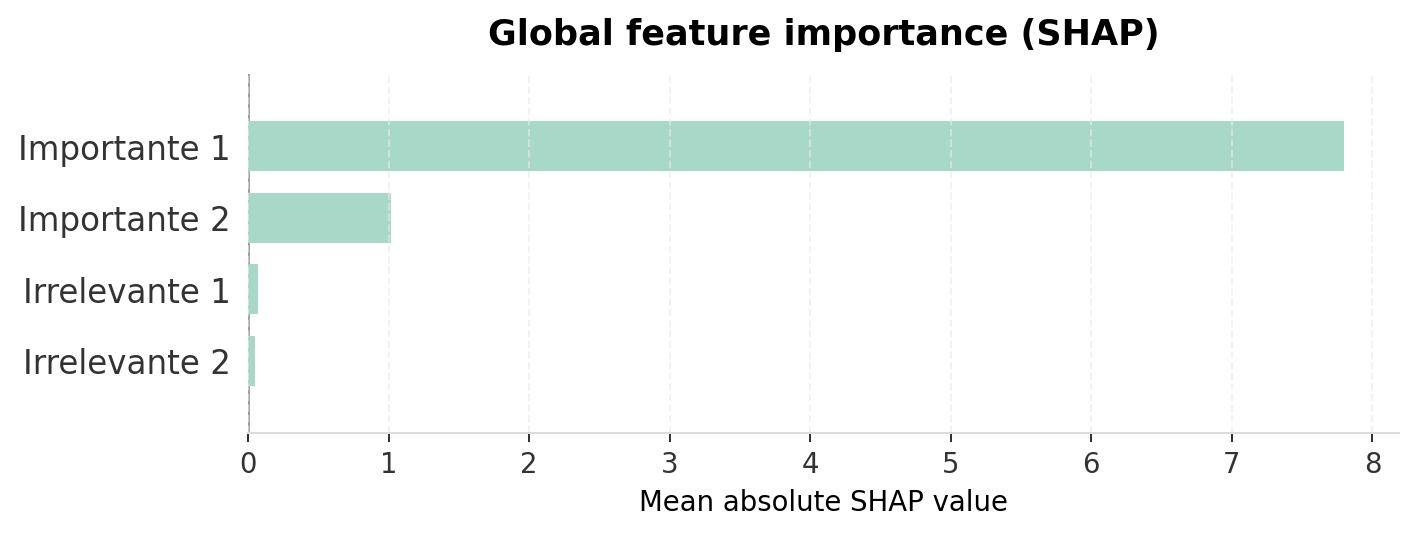

In [5]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# Dados de exemplo
# -----------------------------
rng = np.random.RandomState(1)
n = 300

df_toy = pd.DataFrame({
    "Importante 1": rng.uniform(0, 10, n),
    "Importante 2": rng.uniform(0, 10, n),
    "Irrelevante 1": rng.uniform(0, 10, n),
    "Irrelevante 2": rng.uniform(0, 10, n),
})

# y depende fortemente de importante_1, um pouco de importante_2, e nada das outras duas
y_toy = (
    3.0 * df_toy["Importante 1"]
    + 0.5 * df_toy["Importante 2"]
    + rng.normal(0, 1, n)
)

# -----------------------------
# Modelo
# -----------------------------
modelo_toy = RandomForestRegressor(
    n_estimators=200,
    random_state=0
).fit(df_toy, y_toy)

explainer_toy = shap.TreeExplainer(modelo_toy)
shap_values_toy = explainer_toy.shap_values(df_toy)

# -----------------------------
# Estilo pastel
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "figure.dpi": 180,
    "font.size": 11,
    "font.family": "DejaVu Sans",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#DDDDDD",
    "axes.linewidth": 0.8,
    "grid.color": "#EAEAEA",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
})

# -----------------------------
# Gráfico SHAP
# -----------------------------
shap.summary_plot(
    shap_values_toy,
    df_toy,
    plot_type="bar",
    color="#A8D8C8",   # verde pastel
    show=False
)

ax = plt.gca()
ax.set_title(
    "Global feature importance (SHAP)",
    fontsize=14,
    pad=12,
    weight="semibold"
)
ax.set_xlabel("Mean absolute SHAP value", fontsize=11)
ax.grid(axis="x")

# remover bordas superiores e direitas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

O gráfico deve mostrar `importante_1` com a maior barra, `importante_2` bem menor, e as duas
variáveis irrelevantes próximas de zero — exatamente como foi construído o exemplo. É esse mesmo
raciocínio que, no notebook `03`, identifica `Soma_V015` (outros parentes no domicílio) como a
variável dominante na predição do déficit habitacional real.


## 4. Permutation Importance

Uma forma mais simples (e independente do algoritmo usado) de medir a importância de uma
variável: **embaralhar seus valores** entre as linhas (quebrando sua relação com as demais
variáveis e com o alvo) e medir o quanto o desempenho do modelo piora.

- Se embaralhar uma variável **não muda muito** o desempenho → o modelo não depende muito dela;
- Se embaralhar uma variável **piora muito** o desempenho → o modelo depende fortemente dela.

Diferente do SHAP (que decompõe cada predição individual), a Permutation Importance mede
importância **global**, olhando o impacto agregado no conjunto de teste. Por isso, no notebook
`03`, as duas técnicas são usadas **em conjunto**: quando concordam sobre quais variáveis são mais
importantes, isso reforça a confiança nos resultados (elas usam lógicas bem diferentes para
chegar à mesma conclusão).


In [6]:
from sklearn.inspection import permutation_importance

perm_toy = permutation_importance(
    modelo_toy, df_toy, y_toy, n_repeats=30, random_state=0, scoring="r2"
)

for nome, importancia in sorted(
    zip(df_toy.columns, perm_toy.importances_mean), key=lambda x: -x[1]
):
    print(f"{nome:15s} -> importância média: {importancia:.3f}")


Importante 1    -> importância média: 1.928
Importante 2    -> importância média: 0.044
Irrelevante 1   -> importância média: 0.002
Irrelevante 2   -> importância média: 0.002


## 5. Desagregação espacial por escores de propensão

Este é o núcleo metodológico da fase final do projeto. O problema: sabemos o déficit total de uma
Área de Ponderação (AP), mas **não sabemos como ele se distribui** entre os setores censitários
que a compõem — só temos, para cada setor, características do Censo (não o déficit em si).

**A ideia:** usar um modelo treinado nas APs para gerar, para cada setor, um número que **não é o
déficit**, mas sim uma medida relativa de "propensão" a ter déficit alto, dada as características
daquele setor. Depois, usamos essas propensões apenas como **pesos** para repartir o total
conhecido da AP.

### Exemplo numérico simples

Imagine uma AP com déficit total conhecido = **900** unidades, dividida em 3 setores censitários.
O modelo, aplicado a cada setor, gera os seguintes escores de propensão (números sem significado
absoluto, só usados para comparação relativa):


In [7]:
import pandas as pd

exemplo = pd.DataFrame({
    "setor": ["Setor A", "Setor B", "Setor C"],
    "escore_propensao": [50, 30, 20],
})

deficit_total_ap = 900

exemplo["peso"] = exemplo["escore_propensao"] / exemplo["escore_propensao"].sum()
exemplo["deficit_estimado"] = exemplo["peso"] * deficit_total_ap

display(exemplo)
print("Soma dos setores:", exemplo["deficit_estimado"].sum(), "(deve ser igual a", deficit_total_ap, ")")


,setor,escore_propensao,peso,deficit_estimado
0,Setor A,50,0.5,450.0
1,Setor B,30,0.3,270.0
2,Setor C,20,0.2,180.0


Soma dos setores: 900.0 (deve ser igual a 900 )


O Setor A, com a maior propensão relativa (50 de 100 pontos, ou 50%), recebe metade do déficit da
AP (450 de 900). A soma dos três setores é, por construção, **exatamente igual** ao total da AP —
essa é a propriedade central do método, verificada como "auditoria" no notebook `03` com dados
reais (onde as diferenças observadas foram da ordem de 10⁻¹³, compatíveis com erro numérico de
ponto flutuante).

**O que este método garante, e o que ele não garante:**
- Garante que a soma dos setores sempre bate com o total da AP (consistência agregada).
- Usa características reais de cada setor para diferenciar quem recebe mais ou menos déficit.
- Não garante que a distribuição *dentro* da AP seja perfeita — depende da qualidade do modelo
  de propensão. Por isso a etapa de interpretabilidade (SHAP/Permutation Importance) e de
  validação espacial (Moran/LISA) são tão importantes: elas são as evidências indiretas de que
  a propensão aprendida pelo modelo faz sentido.


## 6. Autocorrelação espacial: Índice de Moran e LISA

Depois de estimar o déficit em cada setor, uma pergunta natural surge: **o resultado faz sentido
no espaço**? Setores vizinhos deveriam, em geral, ter valores parecidos (fenômenos urbanos como
pobreza e infraestrutura tendem a ser territorialmente contínuos, não aleatórios setor a setor).

O **Índice de Moran Global** mede exatamely isso, numa escala de aproximadamente -1 a +1:

- **Próximo de +1:** forte autocorrelação positiva — vizinhos parecidos (padrão de "manchas");
- **Próximo de 0:** ausência de autocorrelação — distribuição espacialmente aleatória;
- **Próximo de -1:** autocorrelação negativa — padrão de "tabuleiro de xadrez" (vizinhos muito
  diferentes entre si), incomum em fenômenos socioeconômicos.

### Demonstração simplificada (sem depender de shapefiles)

Para ilustrar a intuição sem precisar de dados geográficos reais, criamos uma grade 10×10 de
"setores" fictícios, com um padrão espacial propositalmente construído (valores mais altos no
canto superior-esquerdo, mais baixos no canto inferior-direito), e calculamos o Índice de Moran
"na mão", usando vizinhança de grade (cada célula vizinha às células acima/abaixo/esquerda/direita).


In [8]:
import numpy as np

rng = np.random.RandomState(0)
tamanho = 10

# Padrão espacial artificial: gradiente + ruído pequeno
grade = np.fromfunction(lambda i, j: (tamanho - i) + (tamanho - j), (tamanho, tamanho))
grade = grade + rng.normal(0, 1.5, size=grade.shape)

def moran_I_grade(matriz):
    """Calcula o Índice de Moran para uma grade 2D, com vizinhança de 4 células (rook)."""
    n = matriz.size
    valores = matriz.flatten()
    media = valores.mean()
    desvios = valores - media

    numerador = 0.0
    soma_pesos = 0.0
    linhas, colunas = matriz.shape

    for i in range(linhas):
        for j in range(colunas):
            vizinhos = []
            if i > 0: vizinhos.append((i - 1, j))
            if i < linhas - 1: vizinhos.append((i + 1, j))
            if j > 0: vizinhos.append((i, j - 1))
            if j < colunas - 1: vizinhos.append((i, j + 1))

            for (vi, vj) in vizinhos:
                numerador += desvios[i * colunas + j] * desvios[vi * colunas + vj]
                soma_pesos += 1

    denominador = (desvios ** 2).sum()
    return (n / soma_pesos) * (numerador / denominador)

I_grade_estruturada = moran_I_grade(grade)
I_grade_aleatoria = moran_I_grade(rng.normal(0, 1, size=(tamanho, tamanho)))

print(f"Moran I (grade com padrão espacial): {I_grade_estruturada:.3f}")
print(f"Moran I (grade totalmente aleatória): {I_grade_aleatoria:.3f}")


Moran I (grade com padrão espacial): 0.799
Moran I (grade totalmente aleatória): 0.068


A grade **com padrão espacial** (gradiente suave) deve apresentar um Moran I bem mais alto e
positivo do que a grade **aleatória** (próxima de zero). É esse mesmo tipo de cálculo — só que
usando vizinhança por proximidade geográfica real (KNN com k=8) e a biblioteca `esda` — que gerou
o resultado do notebook `03`: **Moran I = 0,52** para o déficit habitacional desagregado no
estado de São Paulo, confirmando um padrão espacial real e não fruto do acaso.

### LISA — onde está a autocorrelação?

O Moran Global dá **um único número para o estado inteiro**. O **LISA (Local Indicators of
Spatial Association)**, de Anselin (1995), calcula uma versão local desse índice **para cada
setor individualmente**, permitindo classificar cada um em:

- **HH (Alto-Alto):** setor de déficit alto, cercado por déficit alto → núcleo de vulnerabilidade;
- **LL (Baixo-Baixo):** setor de déficit baixo, cercado por déficit baixo → área mais favorecida;
- **HL / LH:** setor que destoa dos vizinhos → possível zona de transição, ou ruído local.

Essa classificação, aplicada aos dados reais no notebook `03`, identificou aproximadamente 15,6%
dos setores paulistas como núcleos **HH** — as áreas prioritárias, do ponto de vista territorial,
para políticas públicas habitacionais.
